# 1. Bibliotecas

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# 2. Exploração inicial dos dados

## 2.1 Dimensões

In [2]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.shape

(7043, 21)

## 2.2 Primeiras observações

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2.3 Tipos das variaveis

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### Observações
As variaveis **SeniorCitzen** e **tenure** estão armazenadas como inteiros, enquanto **MonthlyCharges** está armazenado como float.

As demais variáveis estão como Object. Porem **TotalCharges** é uma numérica armazenada como object, então terá que ser convertida durante o tratamento.

## 2.4 Verificação

In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
(df['TotalCharges'].str.strip() == '').sum()

np.int64(11)

# 3. Tratamento inicial dos dados

## 3.1 Conversão de tipos e tratamento de valores ausentes
Conversão das variáveis para os tipos adequados e tratamento dos valores ausentes identificados durante a exploração inicial.

In [8]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [9]:
df[df['tenure'] == 0][['customerID','tenure', 'MonthlyCharges','Churn']]

,customerID,tenure,MonthlyCharges,Churn
488,4472-LVYGI,0,52.55,No
753,3115-CZMZD,0,20.25,No
936,5709-LVOEQ,0,80.85,No
1082,4367-NUYAO,0,25.75,No
1340,1371-DWPAZ,0,56.05,No
3331,7644-OMVMY,0,19.85,No
3826,3213-VVOLG,0,25.35,No
4380,2520-SGTTA,0,20.00,No
5218,2923-ARZLG,0,19.70,No
6670,4075-WKNIU,0,73.35,No


In [10]:
df.loc[df["TotalCharges"].isnull(), "TotalCharges"] = 0
df["TotalCharges"].isnull().sum()

np.int64(0)

### Tratamento de **TotalCharges**
Depois de converter TotalCharges para númerico foi identificado 11 valores ausentes

Investigando esses registos encontrei que todos apresentam **tenure = 0** e **Churn = N**. Isso indica que todos são clientes recentes sem **TotalCharges** acumulado.

Considerando isso os valores nulos foram substituidos por 0, preservando os registros.

## 3.2 Validações

Após o tratamento foi verificado se as tranformações foram aplicadas corretamente e os valores devidamente tratados.

In [11]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [12]:
df.isnull().sum().sum()

np.int64(0)

In [13]:
df[['SeniorCitizen', 'tenure','MonthlyCharges','TotalCharges']].describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


##3.3 Exportação

In [14]:
df.to_csv('../data/processed/churn_tratado.csv', index=False)

# 4. Ánalise da variavel target

In [15]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

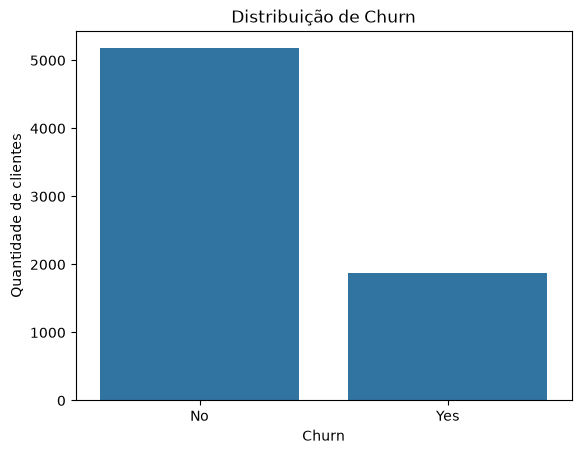

In [16]:
sns.countplot(data=df, x='Churn')
plt.title('Distribuição de Churn')
plt.xlabel('Churn')
plt.ylabel('Quantidade de clientes')
plt.show()

### Observações
A variavel **Churn** tem uma distribuição de 26.53% para clientes que cancelam.

Temos um desbalanceamento entre as classses, com predominancia da classe *No* (não cancelam).

# 5. Analise das variaveis numéricas

## 5.1 Tenure

In [17]:
df['tenure'].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

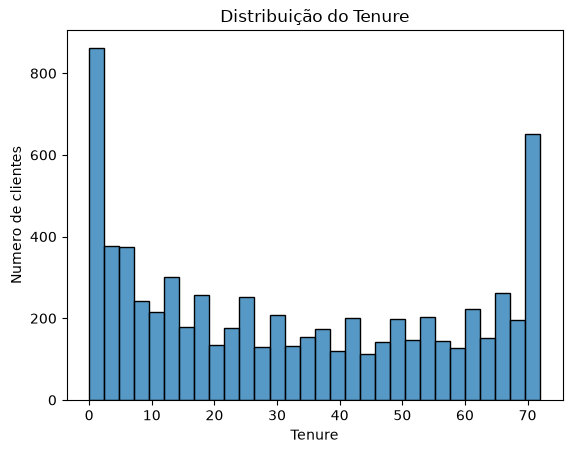

In [18]:
sns.histplot(data=df, x='tenure',bins=30)
plt.title('Distribuição do Tenure')
plt.xlabel('Tenure')
plt.ylabel('Numero de clientes')
plt.show()

In [19]:
df['tenure'].skew()

np.float64(0.2395397495619829)

### Observaões

O histograma tem um padrão proximo de uma distribuição bimodal.

Temos um coeficiente de assimetria de **0.239** indicando leve assimetria positiva a direita

## 5.2 MonthlyCharges

In [20]:
df['MonthlyCharges'].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

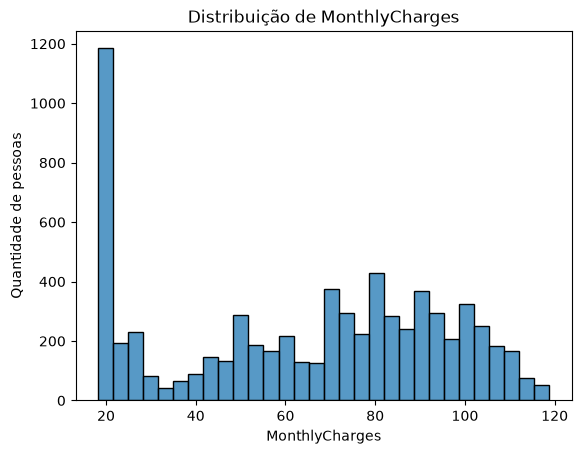

In [21]:
sns.histplot(data=df, x='MonthlyCharges', bins=30)
plt.title('Distribuição de MonthlyCharges')
plt.xlabel('MonthlyCharges')
plt.ylabel('Quantidade de pessoas')
plt.show()

In [22]:
df['MonthlyCharges'].skew()

np.float64(-0.22052443394398033)

### Observações
A distribuição de **MonthlyCharges** apresenta maior concentração de valores entre aproximadamente 70 e 100.

Temos um coeficiente de assimetria de **-0.22** indicando leve assimetria negativa a direita

## 5.3 TotalCharges

In [23]:
df['TotalCharges'].describe()

count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
25%       398.550000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64

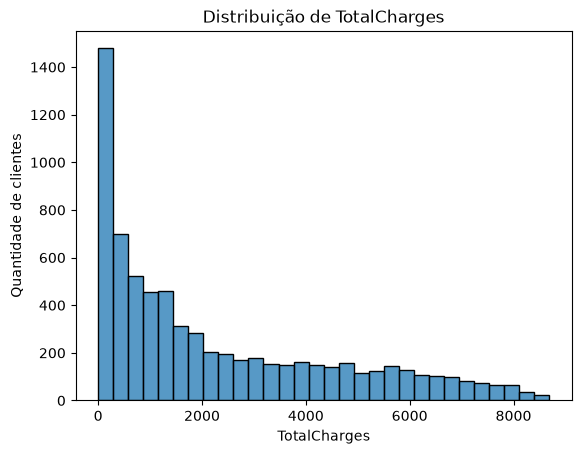

In [24]:
sns.histplot(data=df, x='TotalCharges', bins=30)
plt.title('Distribuição de TotalCharges')
plt.xlabel('TotalCharges')
plt.ylabel('Quantidade de clientes')
plt.show()

In [25]:
df['TotalCharges'].skew()

np.float64(0.963234654832277)

### Observações

Grafico de TotalCharges com padrão assimetrico, com pico nos valores mas baixos.

O coeficiente de assimetria foi **0.963** indicando forte assimetria positiva a direita.

# 6. Analise de variaveis categoricas

In [26]:
col_categorias = df.select_dtypes(include=['object', 'string', 'category']).columns.drop(['customerID', 'Churn'])

df[col_categorias].nunique()

gender              2
Partner             2
Dependents          2
PhoneService        2
MultipleLines       3
InternetService     3
OnlineSecurity      3
OnlineBackup        3
DeviceProtection    3
TechSupport         3
StreamingTV         3
StreamingMovies     3
Contract            3
PaperlessBilling    2
PaymentMethod       4
dtype: int64

In [27]:
for col in col_categorias:
  print(f'\n{df[col].value_counts()}')


gender
Male      3555
Female    3488
Name: count, dtype: int64

Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64

TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64

StreamingTV
No                

### Observações
Foi observada predominancia de clientes com **PhoneService** e de cotratos **Month-to-month**

A variável **PaperlessBilling** também tem predominancia de *Yes* e **Dependents** tem predominancia de *No*.

Tambem foi possivel observar algumas relaç~eos entre as variaveis de serviço. Os clientes de **PhoneService** apresentam como **No phone service** em **MultipleLines**. O mesmo tipo de relação é observado em **InternetService** = *No*  que aparecem como **No Internet Service** nos serviços relacionados a internet.

#7. Relação entre variaveis e Churn

## 7.1 Categoricas x Churn

In [28]:
churn_rate = {}

for col in col_categorias:
    churn_rate[col] = (
        df.groupby(col)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
    )

churn_rate

{'gender': gender
 Female    26.920872
 Male      26.160338
 Name: Churn, dtype: float64,
 'Partner': Partner
 No     32.957979
 Yes    19.664903
 Name: Churn, dtype: float64,
 'Dependents': Dependents
 No     31.279140
 Yes    15.450237
 Name: Churn, dtype: float64,
 'PhoneService': PhoneService
 No     24.926686
 Yes    26.709637
 Name: Churn, dtype: float64,
 'MultipleLines': MultipleLines
 No                  25.044248
 No phone service    24.926686
 Yes                 28.609896
 Name: Churn, dtype: float64,
 'InternetService': InternetService
 DSL            18.959108
 Fiber optic    41.892765
 No              7.404980
 Name: Churn, dtype: float64,
 'OnlineSecurity': OnlineSecurity
 No                     41.766724
 No internet service     7.404980
 Yes                    14.611194
 Name: Churn, dtype: float64,
 'OnlineBackup': OnlineBackup
 No                     39.928756
 No internet service     7.404980
 Yes                    21.531494
 Name: Churn, dtype: float64,
 'DeviceP

### Observações

As variáveis **Partner** e **Dependents** apresentam maiores taxas de churn entre clientes com  `No`.

Entre os serviços relacionados à internet, as categorias `No` apresentam mais churns do que às categorias `Yes`, enquanto `No internet service` apresenta menos.

Em **InternetService**, a categoria `Fiber optic` apresenta uma taxa de churn superior outras.

A variável **Contract** apresenta uma diferença relevante entre suas categorias. Contrato `Month-to-month` apresentam taxa de churn de maior, quando comparado aos contratos `One year` e `Two year`.

Em **PaperlessBilling**, clientes da categoria `Yes` apresentam taxa de churn de superior comparado a categoria `No`.

Entre os métodos de pagamento, `Electronic check` apresenta a maior taxa de churn, com aproximadamente 45,29%.

As demais variaveis não apresentam diferenças significativas nesta analise.

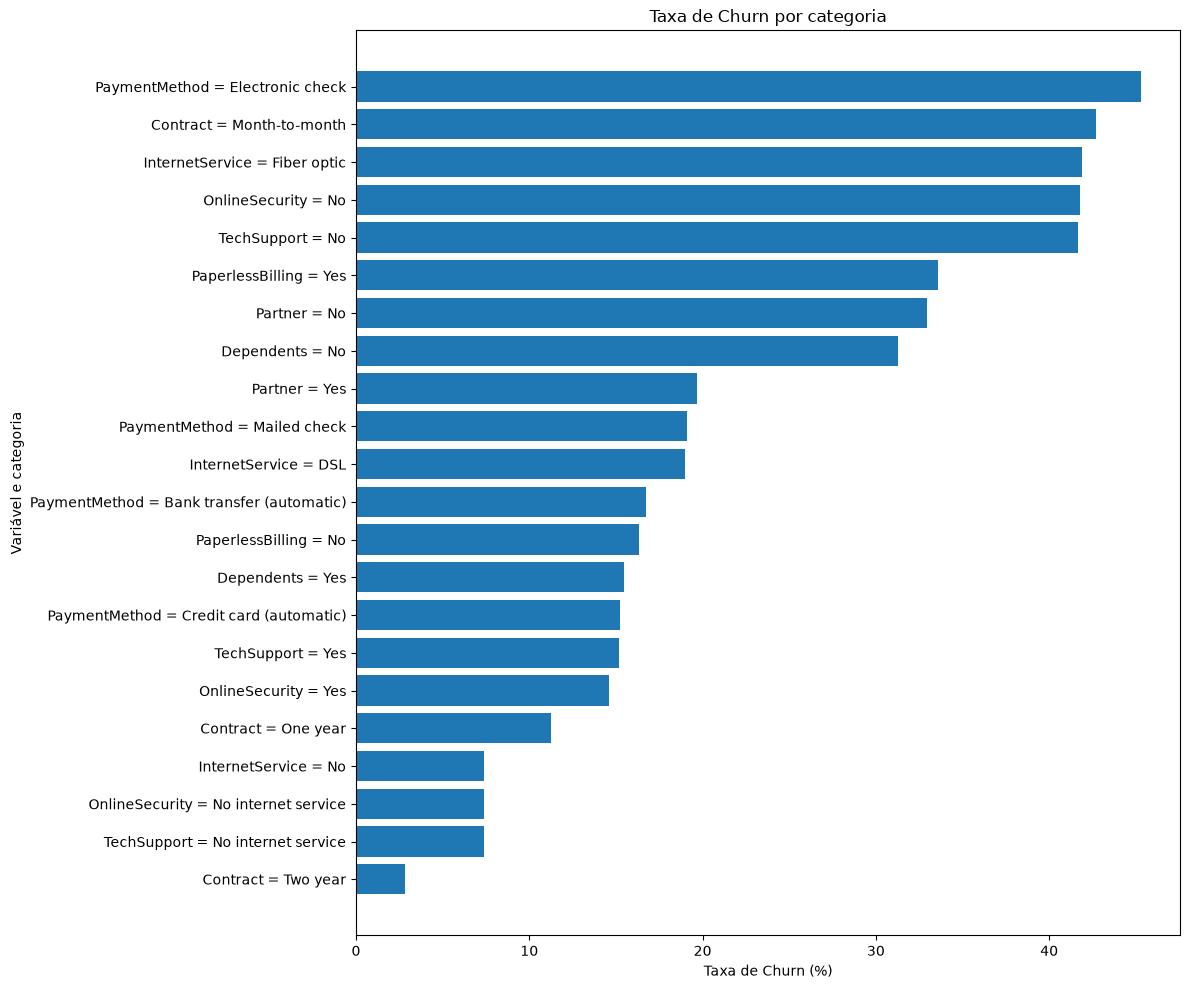

In [29]:
variaveis = [
    "Contract",
    "PaymentMethod",
    "InternetService",
    "OnlineSecurity",
    "TechSupport",
    "Partner",
    "Dependents",
    "PaperlessBilling"
]

dados_grafico = []

for coluna in variaveis:
    taxa = (
        df.groupby(coluna)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
    )

    for categoria, valor in taxa.items():
        dados_grafico.append({
            "variavel": coluna,
            "categoria": categoria,
            "taxa_churn": valor
        })

dados_grafico = pd.DataFrame(dados_grafico)

dados_grafico["rotulo"] = (
    dados_grafico["variavel"] + " = " + dados_grafico["categoria"]
)

dados_grafico = dados_grafico.sort_values("taxa_churn")

plt.figure(figsize=(12, 10))

plt.barh(
    dados_grafico["rotulo"],
    dados_grafico["taxa_churn"]
)

plt.xlabel("Taxa de Churn (%)")
plt.ylabel("Variável e categoria")
plt.title("Taxa de Churn por categoria")

plt.tight_layout()
plt.show()

## 7.2 Numericas x Churn

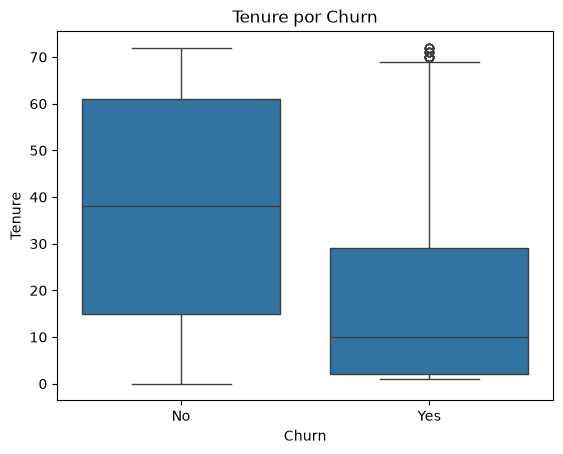

In [30]:
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Tenure por Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure")
plt.show()

### Observações

É observável que os clientes que realizaram churn estão mais concentrados em valores menores de `tenure`, com a mediana próxima de 10 meses, enquanto a mediana dos clientes que não realizaram churn está próxima de 38 meses.

Também podemos observar uma sobreposição entre as distribuições, já que o terceiro quartil de `Churn = Yes` está dentro da distribuição de `Churn = No`.

Existem alguns outliers de `Churn = Yes` próximos de 70 meses de `tenure`, mas ainda não é possível tirar uma conclusão definitiva apenas pela análise visual.

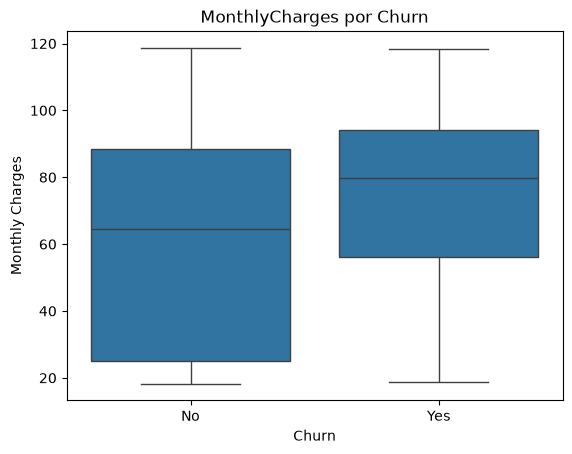

In [31]:
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("MonthlyCharges por Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

### Observações

Os clientes com **Churn = Yes** apresentam valores geralmente mais altos, com mediana próxima de **78**, ja a mediana dos clientes com **Churn = No** está próxima de **65**.

Existe uma grande sobreposição entre as distribuições.

Não foram observados outliers relevantes no gráfico.

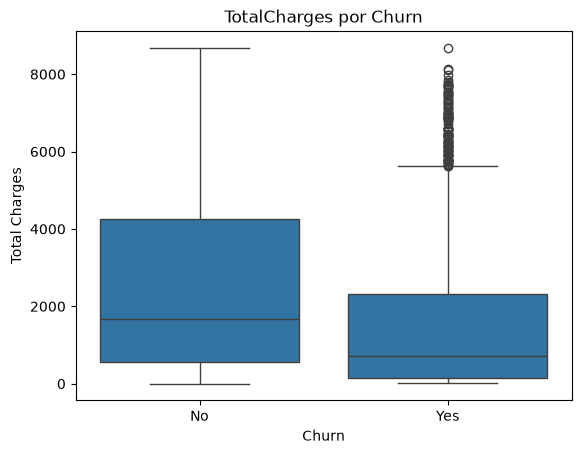

In [32]:
sns.boxplot(data=df, x="Churn", y="TotalCharges")
plt.title("TotalCharges por Churn")
plt.xlabel("Churn")
plt.ylabel("Total Charges")
plt.show()

### Observações

Os clientes com **Churn = Yes** apresentam maior concentração de valores baixos, com mediana próxima de **700**, enquanto a mediana de **Churn = No** está próxima de **1800**.

Existe uma grande sobreposição entre as distribuições.

Também foram observados diversos outliers no grupo **Churn = Yes**, com valores aproximadamente entre **5800 e 8500**.

# 8. Principais observações

## Tratamento e qualidade dos dados

- O dataset possui **7.043 registros e 21 variáveis**.
- Não foram encontrados registros duplicados.
- Valores em branco na variavel **TotalCharges** foram substituidos por 0 para manter os dados já que podem ter relevancia.

## Variáveis numéricas

- **tenure** tem diferença entre os grupos de **Churn**, com clientes que cancelaram apresentando valores menores.
- **MonthlyCharges** apresentou valores de mediana maiores entre os clientes que cancelaram.
- **TotalCharges** apresentou maior concentração de valores baixos entre os clientes que cancelaram.
- **TotalCharges** apresentou assimetria positiva, com coeficiente de **0,963**.

## Variáveis categóricas

- **Contract** apresentou diferenças relevantes nas taxas de churn, principalmente em contratos `Month-to-month`.
- **PaymentMethod** tem maior taxa de churn na categoria `Electronic check`.
- **InternetService** tem maior taxa de churn na categoria `Fiber optic`.
- Variáveis relacionadas a serviços de internet apresentaram mais churn na categoria `No`.
- **Partner** e **Dependents** tem mais churn em clientes da categoria `No`.